In [ ]:
!pip install scikit-fuzzy -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 3.8 MB/s eta 0:00:00


In [ ]:

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl


Input Error: 8
Control Output: 82.78


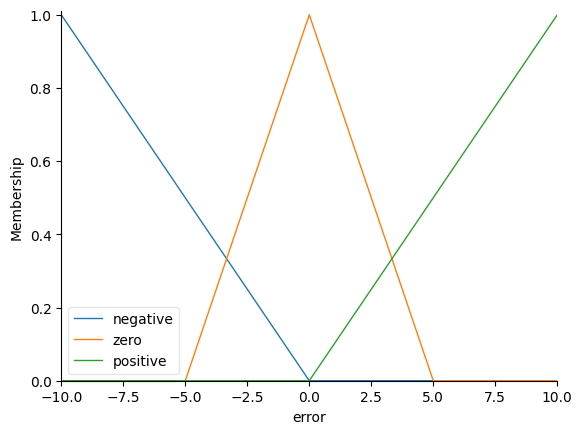

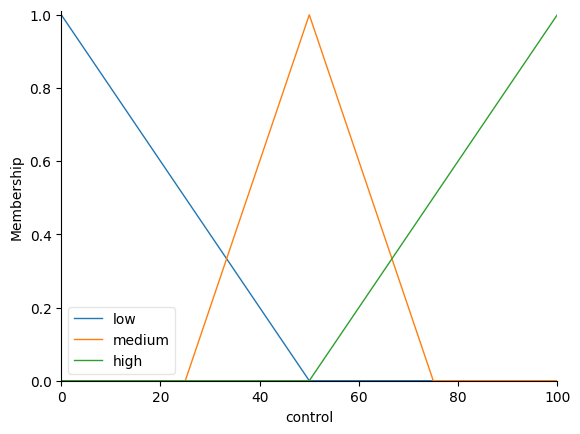

In [ ]:

# Input Variable: Speed Error
error = ctrl.Antecedent(np.arange(-10, 11, 1), 'error')

# Output Variable: Control Signal
control = ctrl.Consequent(np.arange(0, 101, 1), 'control')

# Membership Functions for Error
error['negative'] = fuzz.trimf(error.universe, [-10, -10, 0])
error['zero'] = fuzz.trimf(error.universe, [-5, 0, 5])
error['positive'] = fuzz.trimf(error.universe, [0, 10, 10])

# Membership Functions for Control Signal
control['low'] = fuzz.trimf(control.universe, [0, 0, 50])
control['medium'] = fuzz.trimf(control.universe, [25, 50, 75])
control['high'] = fuzz.trimf(control.universe, [50, 100, 100])

# Fuzzy Rules
rule1 = ctrl.Rule(error['negative'], control['low'])
rule2 = ctrl.Rule(error['zero'], control['medium'])
rule3 = ctrl.Rule(error['positive'], control['high'])

# Control System
system = ctrl.ControlSystem([rule1, rule2, rule3])
simulation = ctrl.ControlSystemSimulation(system)

# Test Input
input_error = 8
simulation.input['error'] = input_error

# Compute Output
simulation.compute()

# Display Result
print("Input Error:", input_error)
print("Control Output:", round(simulation.output['control'], 2))

# Show Membership Functions
error.view()
control.view()

**Exp 2**

In [ ]:
from sklearn.neural_network import MLPRegressor

# Training Data
X_train = [[1], [2], [3], [4], [5]]
y_train = [1, 4, 9, 16, 25]

# Create ANN Model
model = MLPRegressor(
    hidden_layer_sizes=(5,),
    max_iter=3000,
    random_state=1
)

# Train Model
model.fit(X_train, y_train)

# Test Input
X_test = [[6]]

# Predict Output
predicted = model.predict(X_test)

# Display Result
print("Input :", 6)
print("Actual Output :", 36)
print("Predicted Output :", round(predicted[0], 2))

Input : 6
Actual Output : 36
Predicted Output : 26.89


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


**exp3**

In [ ]:
# Simple PID Controller for DC Motor

# PID Parameters
Kp = 2.0
Ki = 0.1
Kd = 0.5

# Desired Speed (RPM)
setpoint = 100

# Initial Values
speed = 0
integral = 0
previous_error = 0

print("Time\tSpeed\tControl")

# Simulation
for t in range(1, 11):

    # Calculate Error
    error = setpoint - speed

    # PID Calculations
    integral = integral + error
    derivative = error - previous_error

    control = (Kp * error) + (Ki * integral) + (Kd * derivative)

    # Simple DC Motor Model
    speed = speed + 0.1 * control

    # Display Results
    print(t, "\t", round(speed, 2), "\t", round(control, 2))

    previous_error = error

Time	Speed	Control
1 	 26.0 	 260.0
2 	 41.24 	 152.4
3 	 54.56 	 133.18
4 	 65.76 	 112.05
5 	 75.17 	 94.12
6 	 83.04 	 78.67
7 	 89.58 	 65.41
8 	 94.98 	 54.03
9 	 99.41 	 44.29
10 	 103.01 	 35.98


**exp4**

In [ ]:
# Simple Adaptive Control System

# Desired Output
setpoint = 100

# Initial Values
output = 0
K = 0.5

# Learning Rate
learning_rate = 0.01

print("Time\tOutput\tGain")

# Simulation
for t in range(1, 11):

    # Calculate Error
    error = setpoint - output

    # Adaptive Gain Update
    K = K + learning_rate * abs(error)

    # Control Action
    output = output + K * error * 0.1

    # Display Results
    print(t, "\t", round(output, 2), "\t", round(K, 2))

Time	Output	Gain
1 	 15.0 	 1.5
2 	 34.98 	 2.35
3 	 54.48 	 3.0
4 	 70.21 	 3.46
5 	 81.39 	 3.75
6 	 88.72 	 3.94
7 	 93.29 	 4.05
8 	 96.06 	 4.12
9 	 97.7 	 4.16
10 	 98.66 	 4.18


**exp5**

In [ ]:
import random

# Objective Function
def fitness(x):
    return x ** 2

# Initial Solution
x = random.uniform(-10, 10)

print("Generation\tBest X\tFitness")

# Genetic Algorithm
for generation in range(1, 11):

    # Mutation
    new_x = x + random.uniform(-1, 1)

    # Selection
    if fitness(new_x) < fitness(x):
        x = new_x

    print(generation, "\t\t", round(x, 4), "\t", round(fitness(x), 4))

print("\nBest Solution")
print("x =", round(x, 4))
print("Minimum Value =", round(fitness(x), 4))

Generation	Best X	Fitness
1 		 -7.7589 	 60.2002
2 		 -7.2044 	 51.9039
3 		 -6.4357 	 41.4188
4 		 -6.4357 	 41.4188
5 		 -5.681 	 32.2742
6 		 -5.3103 	 28.1995
7 		 -5.3103 	 28.1995
8 		 -5.3103 	 28.1995
9 		 -4.4223 	 19.5568
10 		 -3.7475 	 14.0437

Best Solution
x = -3.7475
Minimum Value = 14.0437


**exp6**

In [ ]:
import numpy as np
import random

# Rewards Matrix
R = np.array([
    [-1, -1, -1, -1, 0, -1],
    [-1, -1, -1, 0, -1, 100],
    [-1, -1, -1, 0, -1, -1],
    [-1, 0, 0, -1, 0, -1],
    [0, -1, -1, 0, -1, 100],
    [-1, 0, -1, -1, 0, 100]
])

# Initialize Q Table
Q = np.zeros((6, 6))

gamma = 0.8

# Training
for i in range(100):
    state = random.randint(0, 5)

    while state != 5:
        actions = np.where(R[state] >= 0)[0]
        action = random.choice(actions)

        Q[state, action] = R[state, action] + gamma * np.max(Q[action])

        state = action

# Display Q Table
print("Q Table:")
print(np.round(Q, 2))

# Test the Agent
state = 2

print("\nOptimal Path:")
while state != 5:
    print(state, end=" -> ")
    state = np.argmax(Q[state])

print(5)

Q Table:
[[  0.    0.    0.    0.   80.    0. ]
 [  0.    0.    0.   64.    0.  100. ]
 [  0.    0.    0.   64.    0.    0. ]
 [  0.   80.   51.2   0.   80.    0. ]
 [ 64.    0.    0.   64.    0.  100. ]
 [  0.    0.    0.    0.    0.    0. ]]

Optimal Path:
2 -> 3 -> 1 -> 5


**exp7**

In [ ]:
# Desired Value
setpoint = 1

# Initial Output
output = 0

print("Step\tOutput\tControl")

# MPC Simulation
for step in range(1, 11):

    # Calculate Error
    error = setpoint - output

    # MPC Control Action
    control = 0.5 * error

    # Update System Output
    output = output + control

    # Display Results
    print(step, "\t", round(output, 4), "\t", round(control, 4))

Step	Output	Control
1 	 0.5 	 0.5
2 	 0.75 	 0.25
3 	 0.875 	 0.125
4 	 0.9375 	 0.0625
5 	 0.9688 	 0.0312
6 	 0.9844 	 0.0156
7 	 0.9922 	 0.0078
8 	 0.9961 	 0.0039
9 	 0.998 	 0.002
10 	 0.999 	 0.001


***exp8***

In [ ]:
import heapq

# Graph (Robot Path)
graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'A': 2, 'C': 1, 'D': 7},
    'C': {'A': 4, 'B': 1, 'D': 3},
    'D': {'B': 7, 'C': 3}
}

# Dijkstra Algorithm
def dijkstra(graph, start):

    distance = {node: float('inf') for node in graph}
    distance[start] = 0

    pq = [(0, start)]

    while pq:

        dist, node = heapq.heappop(pq)

        for neighbor, cost in graph[node].items():

            new_dist = dist + cost

            if new_dist < distance[neighbor]:

                distance[neighbor] = new_dist
                heapq.heappush(pq, (new_dist, neighbor))

    return distance

# Run Algorithm
result = dijkstra(graph, 'A')

print("Shortest Distance from A")

for node, dist in result.items():
    print(node, "=", dist)

Shortest Distance from A
A = 0
B = 2
C = 3
D = 6


**exp10**

In [ ]:
import random

# Objective Function (Target at x = 5)
def fitness(x):
    return (x - 5) ** 2

# Initialize Particles
particles = [random.uniform(0, 10) for _ in range(5)]
velocity = [0] * 5
pbest = particles[:]
gbest = min(pbest, key=fitness)

print("Iteration\tGlobal Best\tFitness")

# PSO Iterations
for i in range(1, 11):

    for j in range(5):

        # Update Velocity
        velocity[j] = (
            0.5 * velocity[j]
            + 0.5 * (pbest[j] - particles[j])
            + 0.5 * (gbest - particles[j])
        )

        # Update Position
        particles[j] = particles[j] + velocity[j]

        # Update Personal Best
        if fitness(particles[j]) < fitness(pbest[j]):
            pbest[j] = particles[j]

    # Update Global Best
    gbest = min(pbest, key=fitness)

    print(i, "\t\t", round(gbest, 2), "\t\t",
          round(fitness(gbest), 4))

print("\nOptimal Position =", round(gbest, 2))
print("Minimum Fitness =", round(fitness(gbest), 4))

Iteration	Global Best	Fitness
1 		 4.88 		 0.0136
2 		 4.88 		 0.0136
3 		 4.88 		 0.0136
4 		 5.08 		 0.0072
5 		 4.98 		 0.0003
6 		 4.98 		 0.0003
7 		 5.01 		 0.0001
8 		 5.0 		 0.0
9 		 5.0 		 0.0
10 		 5.0 		 0.0

Optimal Position = 5.0
Minimum Fitness = 0.0


**SECOND SET EXP 1**

Temperature: 30
Fan Speed: 80.56


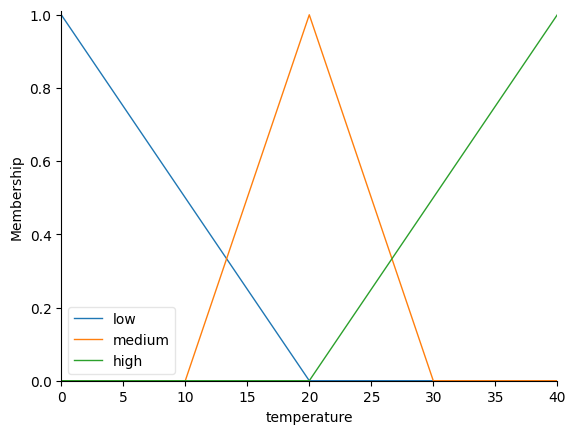

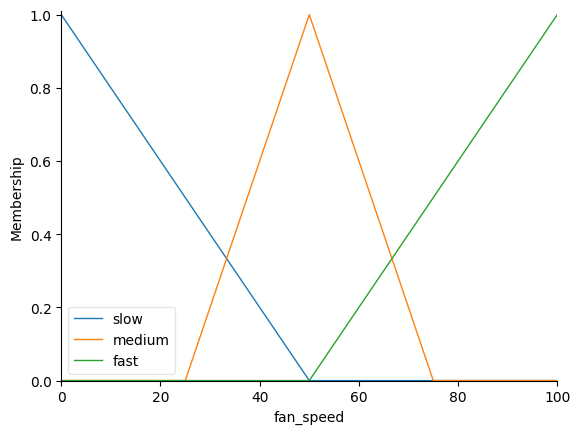

In [ ]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

# Input Variable: Temperature
temperature = ctrl.Antecedent(
    np.arange(0, 41, 1),
    'temperature'
)

# Output Variable: Fan Speed
fan_speed = ctrl.Consequent(
    np.arange(0, 101, 1),
    'fan_speed'
)

# Membership Functions
temperature['low'] = fuzz.trimf(
    temperature.universe,
    [0, 0, 20]
)

temperature['medium'] = fuzz.trimf(
    temperature.universe,
    [10, 20, 30]
)

temperature['high'] = fuzz.trimf(
    temperature.universe,
    [20, 40, 40]
)

fan_speed['slow'] = fuzz.trimf(
    fan_speed.universe,
    [0, 0, 50]
)

fan_speed['medium'] = fuzz.trimf(
    fan_speed.universe,
    [25, 50, 75]
)

fan_speed['fast'] = fuzz.trimf(
    fan_speed.universe,
    [50, 100, 100]
)

# Rules
rule1 = ctrl.Rule(
    temperature['low'],
    fan_speed['slow']
)

rule2 = ctrl.Rule(
    temperature['medium'],
    fan_speed['medium']
)

rule3 = ctrl.Rule(
    temperature['high'],
    fan_speed['fast']
)

# Control System
system = ctrl.ControlSystem(
    [rule1, rule2, rule3]
)

simulation = ctrl.ControlSystemSimulation(
    system
)

# Test Input
simulation.input['temperature'] = 30

# Compute Output
simulation.compute()

# Display Result
print("Temperature:", 30)
print(
    "Fan Speed:",
    round(
        simulation.output['fan_speed'],
        2
    )
)

# Show Membership Functions
temperature.view()
fan_speed.view()

**EXP 2**

In [ ]:
from sklearn.neural_network import MLPRegressor

# Training Data
X_train = [[1], [2], [3], [4], [5]]
y_train = [5, 7, 9, 11, 13]

# Create ANN Model
model = MLPRegressor(
    hidden_layer_sizes=(5,),
    max_iter=2000,
    random_state=1
)

# Train Model
model.fit(X_train, y_train)

# Test Input
X_test = [[6]]

# Predict Output
predicted = model.predict(X_test)

# Display Result
print("Input :", 6)
print("Predicted Output :", round(predicted[0], 2))

Input : 6
Predicted Output : 15.6


**Exp 3**

In [ ]:
# PID Parameters
Kp = 2.0
Ki = 0.1
Kd = 0.5

# Desired Speed
setpoint = 100

# Initial Values
speed = 0
integral = 0
previous_error = 0

print("Time\tSpeed\tControl")

# Simulation
for t in range(1, 11):

    error = setpoint - speed

    integral = integral + error
    derivative = error - previous_error

    control = (Kp * error) + (Ki * integral) + (Kd * derivative)

    speed = speed + 0.1 * control

    print(t, "\t", round(speed, 2), "\t", round(control, 2))

    previous_error = error

Time	Speed	Control
1 	 26.0 	 260.0
2 	 41.24 	 152.4
3 	 54.56 	 133.18
4 	 65.76 	 112.05
5 	 75.17 	 94.12
6 	 83.04 	 78.67
7 	 89.58 	 65.41
8 	 94.98 	 54.03
9 	 99.41 	 44.29
10 	 103.01 	 35.98


**exp 3**

In [ ]:
# Desired Output
setpoint = 50

# Initial Values
output = 0
gain = 1

print("Time\tOutput\tGain")

# Adaptive Control
for t in range(1, 11):

    error = setpoint - output

    # Update Gain
    gain = gain + 0.01 * error

    # Update Output
    output = output + gain * 0.1

    print(t, "\t", round(output, 2), "\t", round(gain, 2))

Time	Output	Gain
1 	 0.15 	 1.5
2 	 0.35 	 2.0
3 	 0.6 	 2.5
4 	 0.9 	 2.99
5 	 1.25 	 3.48
6 	 1.64 	 3.97
7 	 2.09 	 4.45
8 	 2.58 	 4.93
9 	 3.12 	 5.4
10 	 3.71 	 5.87


**exp 4**

In [ ]:
import random

# Objective Function
def fitness(x):
    return (x - 3) ** 2 + 1

# Initial Solution
x = random.uniform(0, 10)

print("Generation\tBest X\tFitness")

# Genetic Algorithm
for generation in range(1, 11):

    # Mutation
    new_x = x + random.uniform(-1, 1)

    # Selection
    if fitness(new_x) < fitness(x):
        x = new_x

    print(generation, "\t\t", round(x, 2), "\t", round(fitness(x), 4))

print("\nBest Solution =", round(x, 2))
print("Minimum Value =", round(fitness(x), 4))

Generation	Best X	Fitness
1 		 8.08 	 26.8494
2 		 8.01 	 26.1158
3 		 8.01 	 26.1158
4 		 7.38 	 20.197
5 		 7.38 	 20.197
6 		 7.38 	 20.197
7 		 7.38 	 20.197
8 		 7.38 	 20.197
9 		 7.15 	 18.2293
10 		 7.15 	 18.2293

Best Solution = 7.15
Minimum Value = 18.2293


**exp 5**

In [ ]:
import numpy as np
import random

# Reward Matrix
R = np.array([
    [-1, 0, -1, -1],
    [0, -1, 0, 100],
    [-1, 0, -1, 100],
    [-1, -1, -1, 100]
])

# Q Table
Q = np.zeros((4, 4))

gamma = 0.8

# Training
for i in range(100):

    state = random.randint(0, 3)

    actions = np.where(R[state] >= 0)[0]

    if len(actions) > 0:

        action = random.choice(actions)

        Q[state, action] = (
            R[state, action]
            + gamma * np.max(Q[action])
        )

# Display Q Table
print("Q Table")
print(Q)

# Optimal Path
state = 0

print("\nPath:")
while state != 3:
    print(state, end=" -> ")
    state = np.argmax(Q[state])

print(3)

Q Table
[[  0.         398.79107418   0.           0.        ]
 [317.63881676   0.         372.51220931 498.48884273]
 [  0.         398.79107418   0.         498.48884273]
 [  0.           0.           0.         499.22628748]]

Path:
0 -> 1 -> 3


**Experiment No: 16**

In [ ]:
# Desired Position
setpoint = 10

# Initial Position
position = 0

print("Step\tPosition\tControl")

# MPC Simulation
for step in range(1, 11):

    # Calculate Error
    error = setpoint - position

    # Control Action
    control = 0.5 * error

    # Update Position
    position = position + control

    print(step, "\t", round(position, 2), "\t\t", round(control, 2))

Step	Position	Control
1 	 5.0 		 5.0
2 	 7.5 		 2.5
3 	 8.75 		 1.25
4 	 9.38 		 0.62
5 	 9.69 		 0.31
6 	 9.84 		 0.16
7 	 9.92 		 0.08
8 	 9.96 		 0.04
9 	 9.98 		 0.02
10 	 9.99 		 0.01


**17**

In [ ]:
import heapq

# Graph
graph = {
    'A': {'B': 2, 'C': 4},
    'B': {'A': 2, 'C': 1, 'D': 7},
    'C': {'A': 4, 'B': 1, 'D': 3},
    'D': {'B': 7, 'C': 3}
}

# Dijkstra Algorithm
def dijkstra(graph, start):

    distance = {node: float('inf') for node in graph}
    distance[start] = 0

    pq = [(0, start)]

    while pq:

        dist, node = heapq.heappop(pq)

        for neighbor, cost in graph[node].items():

            new_dist = dist + cost

            if new_dist < distance[neighbor]:

                distance[neighbor] = new_dist
                heapq.heappush(pq, (new_dist, neighbor))

    return distance

# Run Algorithm
result = dijkstra(graph, 'A')

print("Shortest Distance from A")

for node, dist in result.items():
    print(node, "=", dist)

Shortest Distance from A
A = 0
B = 2
C = 3
D = 6


**Use Particle Swarm Optimization (PSO) to Find the Maximum Value of \(f(x)=8-(x-2)^2\)**

In [ ]:
import random

# Objective Function
def fitness(x):
    return 8 - (x - 2) ** 2

# Initialize Particles
particles = [random.uniform(0, 5) for _ in range(5)]
velocity = [0] * 5

# Personal Best
pbest = particles[:]

# Global Best (Maximum Fitness)
gbest = max(pbest, key=fitness)

print("Iteration\tGlobal Best\tFitness")

# PSO Iterations
for i in range(1, 11):

    for j in range(5):

        # Update Velocity
        velocity[j] = (
            0.5 * velocity[j]
            + 0.5 * (pbest[j] - particles[j])
            + 0.5 * (gbest - particles[j])
        )

        # Update Position
        particles[j] = particles[j] + velocity[j]

        # Update Personal Best
        if fitness(particles[j]) > fitness(pbest[j]):
            pbest[j] = particles[j]

    # Update Global Best
    gbest = max(pbest, key=fitness)

    print(i, "\t\t", round(gbest, 2), "\t\t",
          round(fitness(gbest), 4))

print("\nOptimal Position =", round(gbest, 2))
print("Maximum Fitness =", round(fitness(gbest), 4))

Iteration	Global Best	Fitness
1 		 1.45 		 7.7001
2 		 2.07 		 7.9955
3 		 2.07 		 7.9955
4 		 2.07 		 7.9955
5 		 1.99 		 7.9999
6 		 1.99 		 7.9999
7 		 1.99 		 7.9999
8 		 1.99 		 7.9999
9 		 1.99 		 7.9999
10 		 2.0 		 8.0

Optimal Position = 2.0
Maximum Fitness = 8.0
